In [1]:
import tempfile
import os
import logging
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import xarray as xr
from IPython.display import display, Markdown, HTML

import oq_wrapper as oqw
import nn_gmm as nng
import ml_tools as mlt

device = "cpu"
if torch.cuda.is_available():
    device = "cuda"

logging.basicConfig(
    format='%(asctime)s - %(levelname)s - %(name)s - %(message)s',
    level=logging.WARNING
)

PLOT_IMS = ["pSA_0.01", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_3.0", "pSA_10.0"]


/Users/claudy/dev/work/code/seismic_hazard_analyis/seismic_hazard_analysis/site_source.py:928: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  scenario_section_ids[i],
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
result_dir = "/Users/claudy/dev/work/data/nn_gmm/results/0808_1618_test_cv"

In [3]:
result_dir = Path(result_dir)
empdb_ffp = Path(os.environ["wdata"]) / "nn_gmm/20250616_CS200m_empdb.db"

In [4]:
display(Markdown("## Inputs\n\n"))
display(Markdown(f"**Result directory**: `{result_dir}`\n\n**Empirical database**: `{empdb_ffp}`"))

## Inputs



**Result directory**: `/Users/claudy/dev/work/data/nn_gmm/results/0808_1618_test_cv`

**Empirical database**: `/Users/claudy/dev/work/data/nn_gmm/20250616_CS200m_empdb.db`

In [5]:
run_config = nng.RunConfig.from_yaml(result_dir / "run_config.yaml")
val_pred_df = pd.read_parquet(result_dir / "val_results.parquet").sort_index()
metrics_da = xr.open_dataarray(result_dir / "metrics.nc")

In [6]:
val_record_int_ids = val_pred_df.index.values.astype(int)

with nng.IMDB(run_config.imdb_ffp, readonly=True) as imdb:
    event_df = imdb.get_event_df()
    site_df = imdb.get_site_df()
    val_sim_df = imdb.get_im_data_tmp_table(run_config.ims, val_record_int_ids).sort_index()
    val_record_info_df = imdb.get_record_info_df(record_int_ids=val_record_int_ids)
    val_site_event_df = imdb.get_site_event_df()

val_sim_df["event_int_id"] = val_record_info_df.loc[val_sim_df.index, "event_int_id"].values
val_sim_df["site_int_id"] = val_record_info_df.loc[val_sim_df.index, "site_int_id"].values
val_sim_df["site_event_int_id"] = nng.utils.get_site_event_int_id(val_sim_df.site_int_id, val_sim_df.event_int_id)
val_sim_df["magnitude"] = event_df.loc[val_sim_df["event_int_id"], "magnitude"].values
val_sim_df["rrup"] = val_site_event_df.loc[val_sim_df["site_event_int_id"], "rrup"].values

val_pred_df["site_int_id"] = val_record_info_df.loc[val_pred_df.index, "site_int_id"].values

assert val_pred_df.index.equals(val_sim_df.index)

2025-08-11 20:47:50,788 - WARNING - nn_gmm.imdb - No filters applied, returning all site-event data. This is slow.


In [7]:
figs = nng.plots_spatial.site_bias_res_std(val_pred_df, val_sim_df, site_df, PLOT_IMS, run_config);

grdimage [ERROR]: Option -Q: Cannot specify a transparent color for grids when intensities are also used
/Users/claudy/dev/work/code/pygmt_helper/pygmt_helper/plotting.py:528: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(
grdimage [ERROR]: Option -Q: Cannot specify a transparent color for grids when intensities are also used
/Users/claudy/dev/work/code/pygmt_helper/pygmt_helper/plotting.py:528: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(
grdimage [ERROR]: Option -Q: Cannot specify a transparent color for grids when intensities are also used
/Users/claudy/dev/work/code/pygmt_helper/pygmt_helper/plotting.py:528: FutureWarning: The 'interval' parameter has been deprecated since v0.12.0 and will be removed in v0.16.0. Please use 'levels' instead.
  fig.grdcontour(
grdimage [ERR

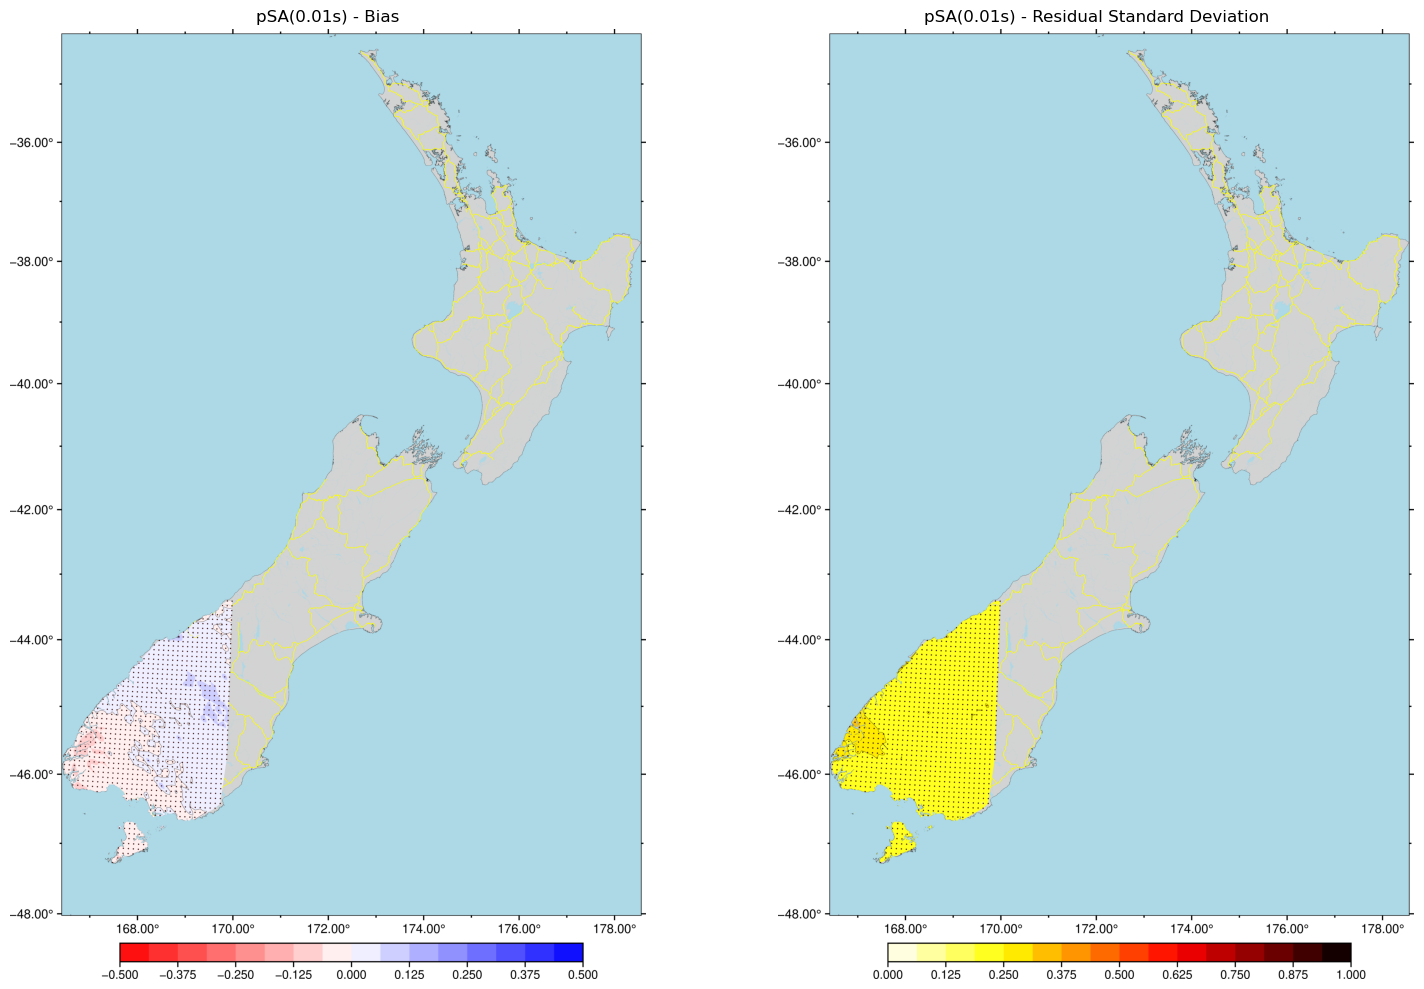

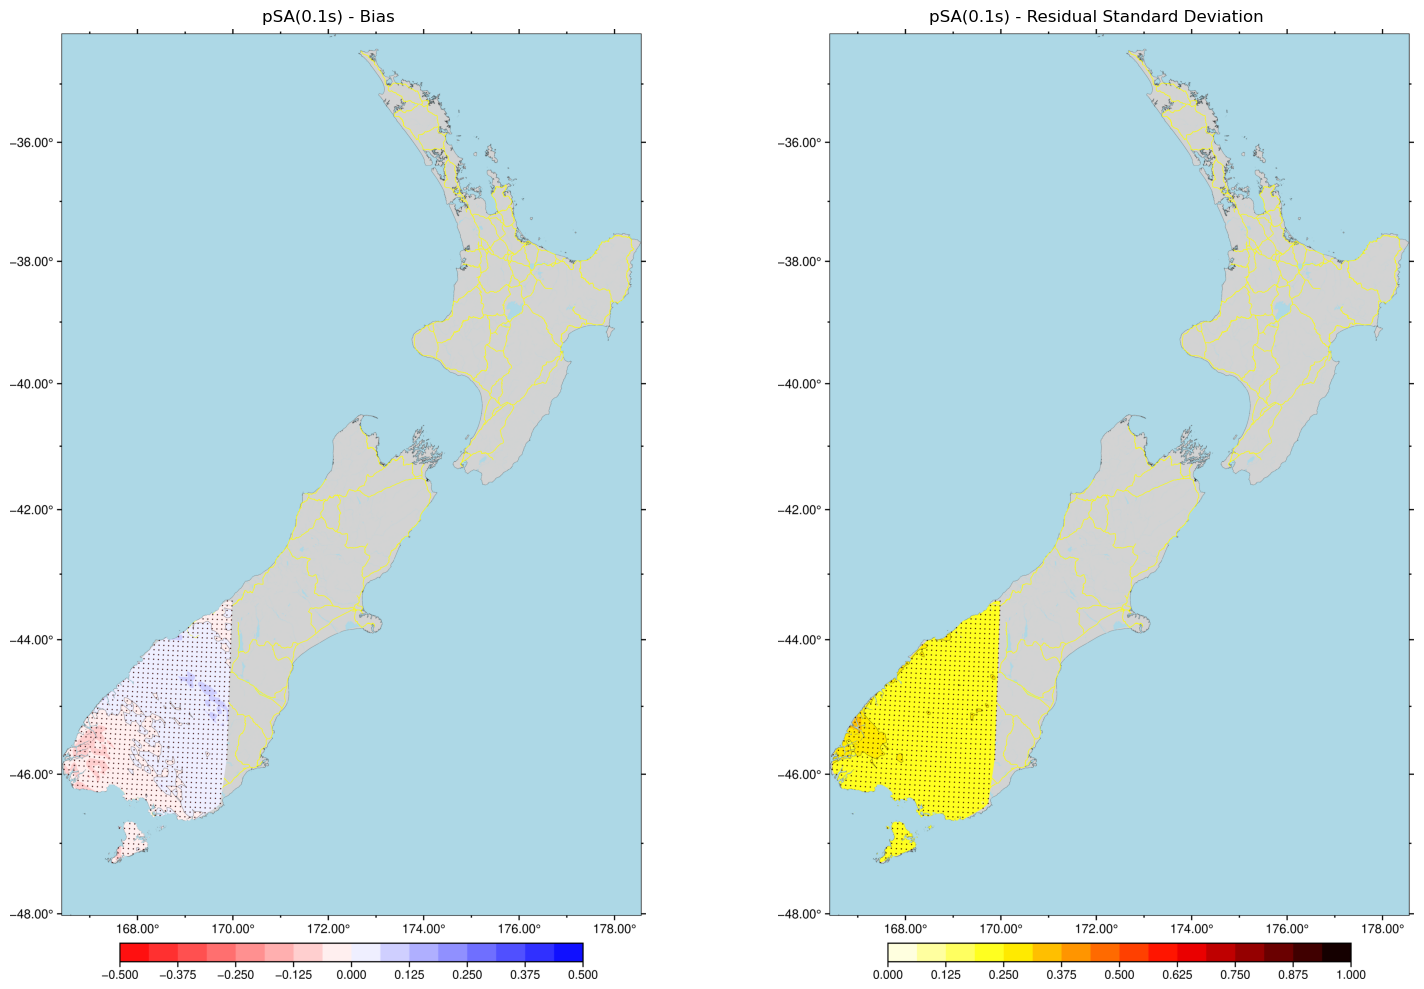

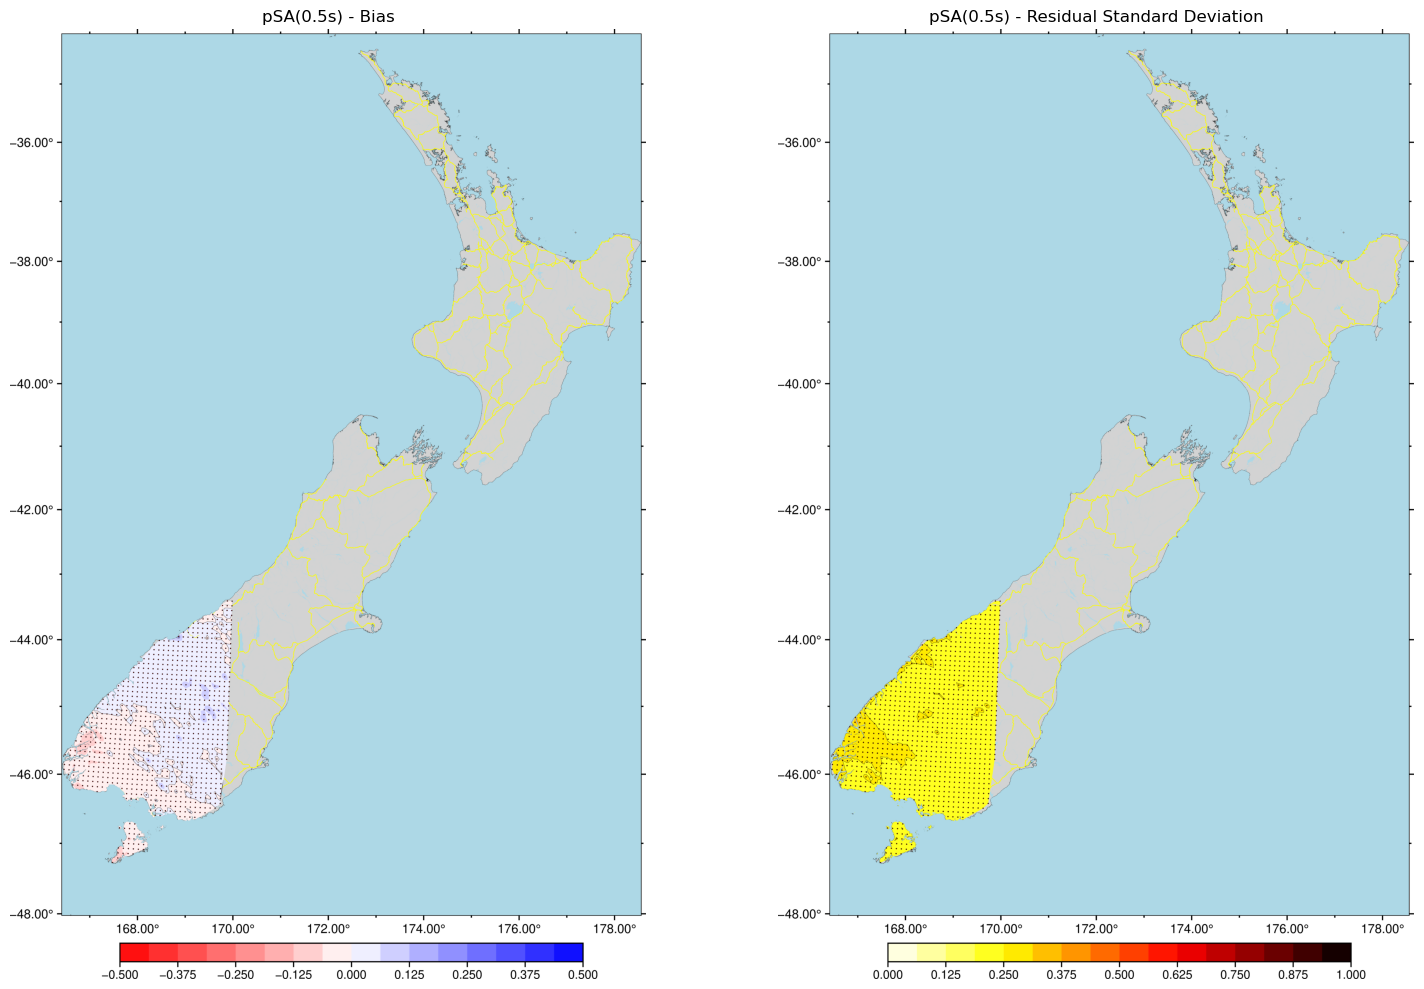

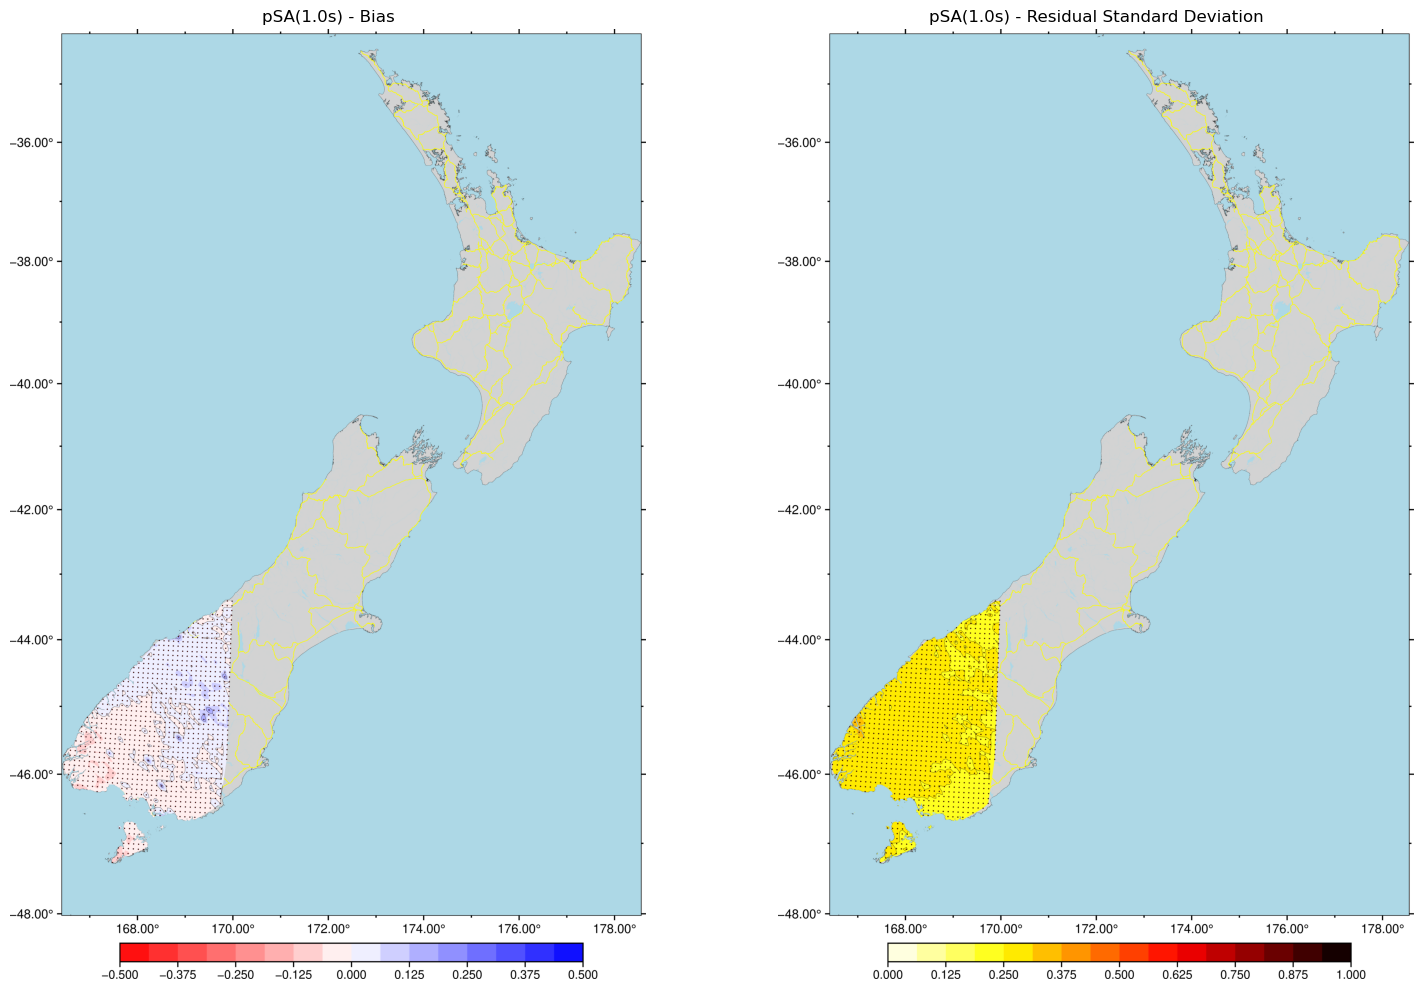

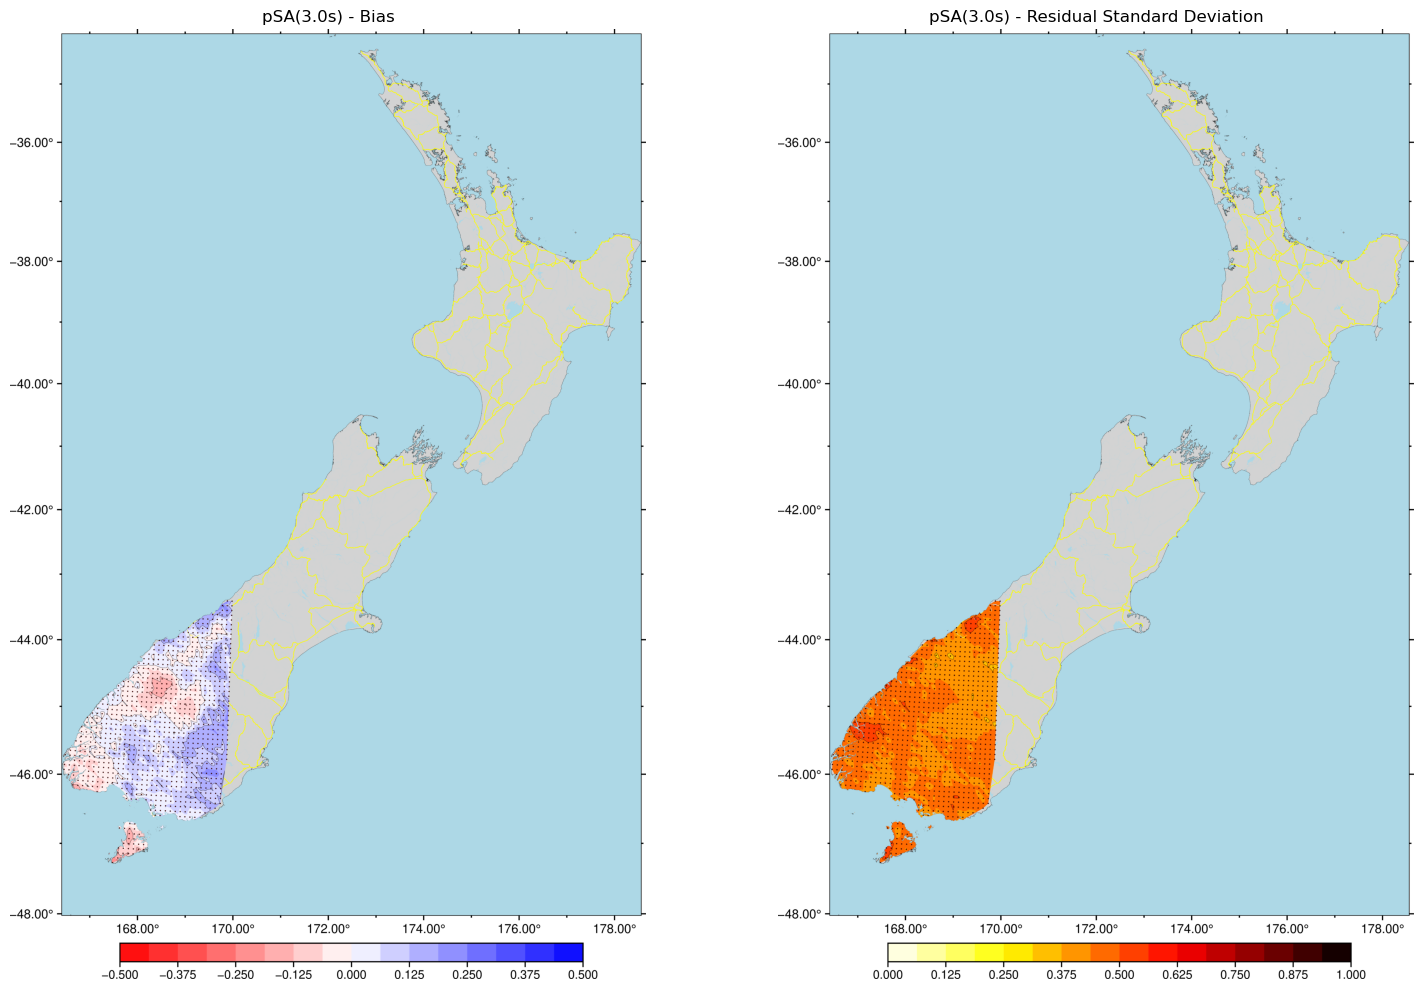

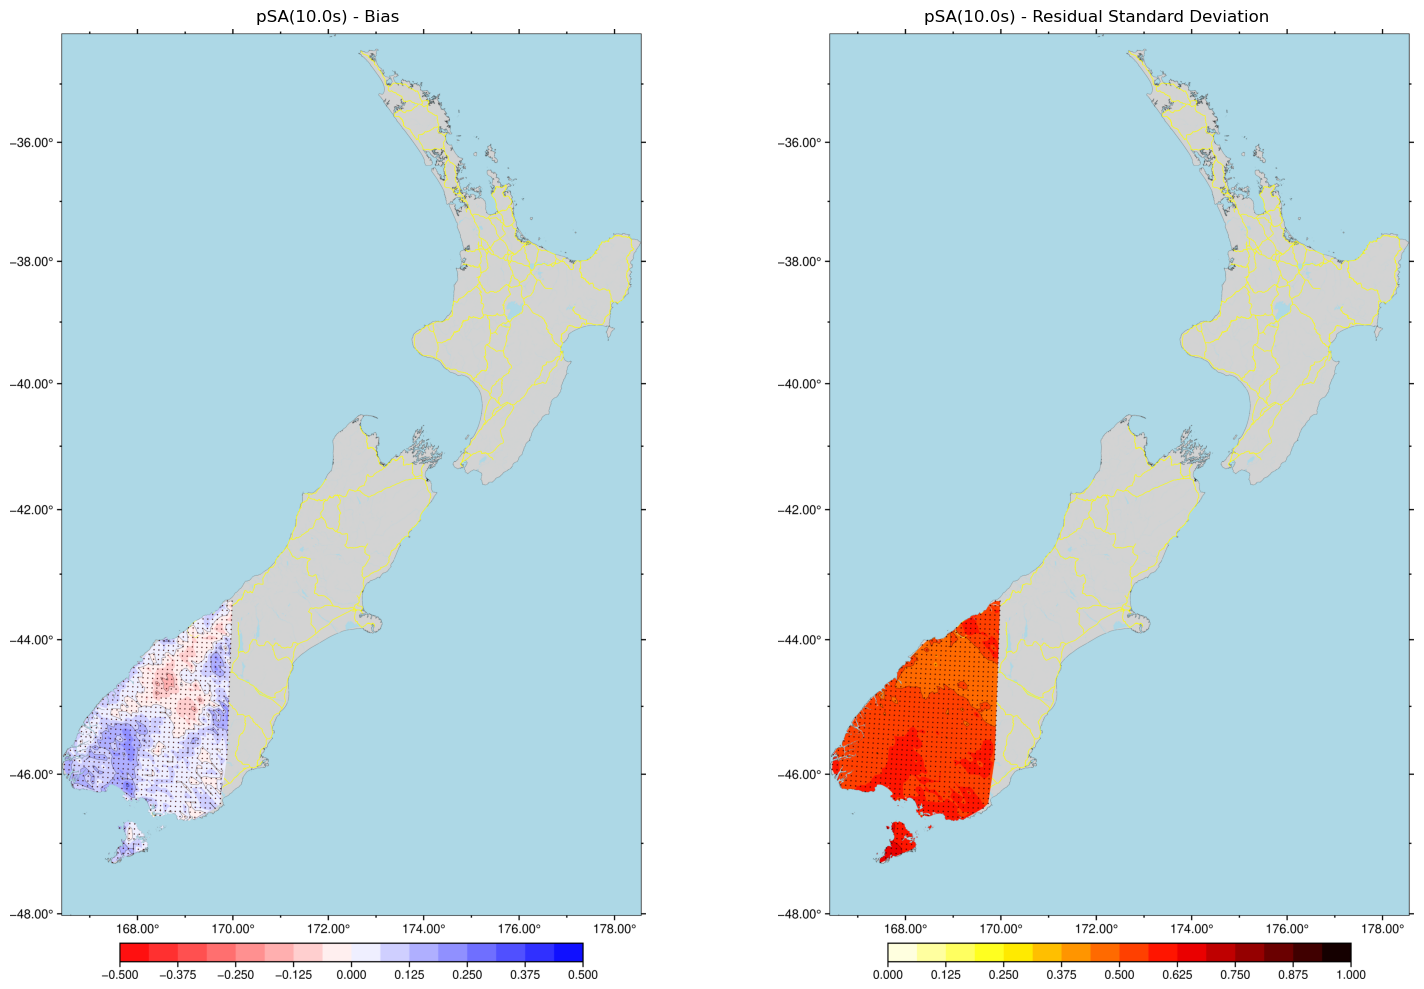

In [8]:
for cur_im in PLOT_IMS:
    fig = nng.plot_utils.pygmt_side_by_side(figs[cur_im][0], figs[cur_im][1], title_1=f"{nng.utils.get_nice_im_name(cur_im)} - Bias", title_2=f"{nng.utils.get_nice_im_name(cur_im)} - Residual Standard Deviation")
    plt.show()